In [1]:
using MLDatasets, Flux
train_data = MLDatasets.FashionMNIST(split=:train)
test_data  = MLDatasets.FashionMNIST(split=:test)

function loader(data; batchsize::Int=1)
    x4dim = reshape(data.features, 28, 28, 1, :) # insert trivial channel dim
    yhot  = Flux.onehotbatch(data.targets, 0:9)  # make a 10×60000 OneHotMatrix
    Flux.DataLoader((x4dim, yhot); batchsize, shuffle=true)
end

net = Chain(
  Conv((3, 3), 1 => 6, pad=1, bias=false),  # 54 parameters
  MaxPool((2, 2)),
  Conv((3, 3), 6 => 16, pad=1, bias=false),  # 864 parameters
  MaxPool((2, 2)),
  Flux.flatten,
  Dense(784 => 84, relu),               # 65_940 parameters
  Dropout(0.4),
  Dense(84 => 10),                      # 850 parameters
)                   # Total: 6 arrays, 67_708 parameters, 265.133 KiB.

In [2]:
x1, y1 = first(loader(train_data))
y1hat = net(x1)
@show hcat(Flux.onecold(y1hat, 0:9), Flux.onecold(y1, 0:9))

using Statistics: mean
function loss_and_accuracy(model, data)
    (x,y) = only(loader(data; batchsize=length(data)))
    ŷ = model(x)
    loss = Flux.logitcrossentropy(ŷ, y)
    acc = round(100 * mean(Flux.onecold(ŷ) .== Flux.onecold(y)); digits=2)
    (; loss, acc, split=data.split)
end

@show loss_and_accuracy(net, test_data); # accuracy about 10%, before training

train_log = []
settings = (;
    eta = 1e-2,
    epochs = 3,
    batchsize = 10,
)
opt_state = Flux.setup(Descent(settings.eta), net);

hcat(Flux.onecold(y1hat, 0:9), Flux.onecold(y1, 0:9)) = [6 4]
loss_and_accuracy(net, test_data) = (loss = 2.3033843f0, acc = 12.82, split = :test)


In [3]:
accuracy = zeros(settings.epochs, 2)
for epoch in 1:settings.epochs
    @time for (x,y) in loader(train_data, batchsize=settings.batchsize)
        grads = Flux.gradient(model -> Flux.logitcrossentropy(model(x), y), net)
        Flux.update!(opt_state, net, grads[1])
    end
    
    loss, acc, _ = loss_and_accuracy(net, train_data)
    test_loss, test_acc, _ = loss_and_accuracy(net, test_data)
    @info epoch acc test_acc
    nt = (; epoch, loss, acc, test_loss, test_acc) 
    push!(train_log, nt)
    accuracy[epoch, 1] = acc
    accuracy[epoch, 2] = test_acc
end

 37.702049 seconds (38.54 M allocations: 9.717 GiB, 3.96% gc time, 52.27% compilation time)
 17.628470 seconds (3.91 M allocations: 8.031 GiB, 6.43% gc time)


┌ Info: 1
│   acc = 84.56
└   test_acc = 83.63


 17.429261 seconds (3.91 M allocations: 8.028 GiB, 5.22% gc time)


┌ Info: 2
│   acc = 86.96
└   test_acc = 85.49
┌ Info: 3
│   acc = 87.87
└   test_acc = 86.2


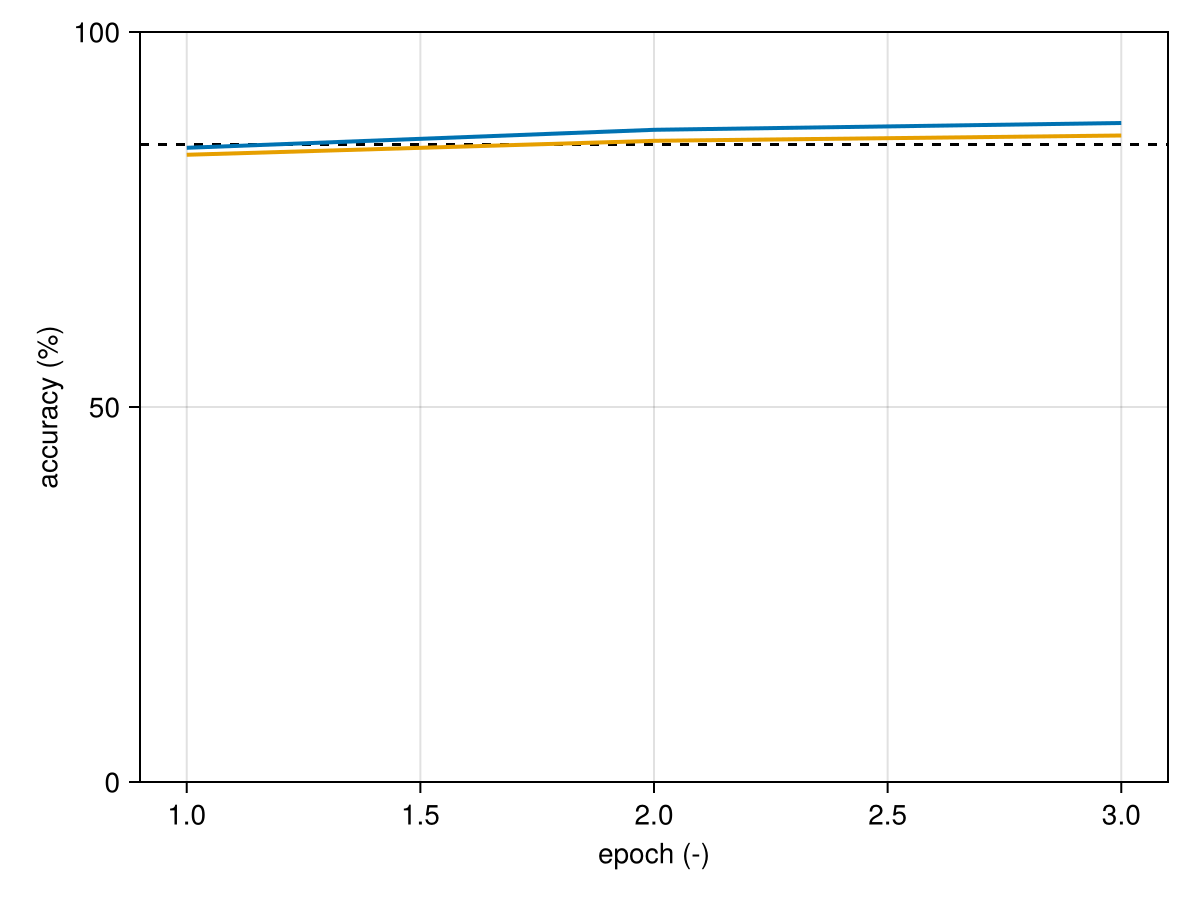

In [4]:
using CairoMakie
fig = Figure()
gca = Axis(fig[1,1], xlabel="epoch (-)", ylabel="accuracy (%)")
hlines!(85, linestyle=:dash, color=:black)
lines!(gca, accuracy[:,1], linewidth=2); ylims!(gca, (0, 100))
lines!(gca, accuracy[:,2], linewidth=2); ylims!(gca, (0, 100))
fig

In [5]:
x1, y1 = first(loader(test_data))
y1hat = net(x1)
@show hcat(Flux.onecold(y1hat, 0:9), Flux.onecold(y1, 0:9))
@show loss_and_accuracy(net, test_data);

hcat(Flux.onecold(y1hat, 0:9), Flux.onecold(y1, 0:9)) = [1 1]
loss_and_accuracy(net, test_data) = (loss = 0.36745292f0, acc = 86.2, split = :test)


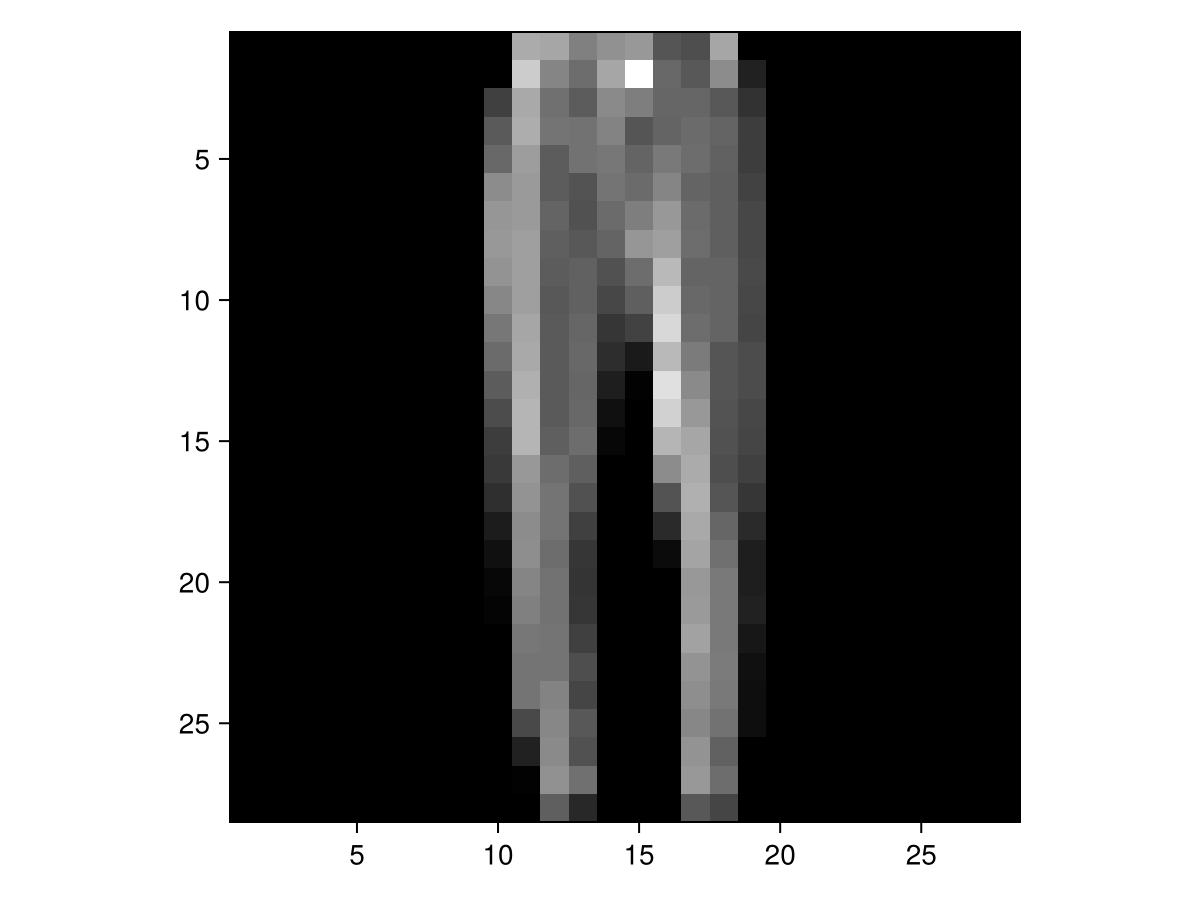

In [6]:
using CairoMakie
heatmap(x1[:,:,1,1], colormap=:bone, axis = (aspect = DataAspect(), yreversed = true))